# Vectorized Mini-Batch Gradient Descent

In modern machine learning libraries, loops over individual data items are replaced with vectorized matrix operations. Vectorization allows hardware accelerators (like GPUs and TPUs) to compute predictions and gradients for an entire mini-batch simultaneously using parallel linear algebra operations.

---

### 1. The Matrix Machine Learning Notation

Instead of treating features and labels as independent scalars or iterating through rows, we pack the data from our active mini-batch $\mathcal{B}$ into multidimensional arrays (matrices and vectors).

Let our mini-batch size be $n$, and assume each data observation has exactly $1$ feature. We define our batch structures at step $t$ as follows:

* $\mathbf{X}$ (**Feature Matrix**): A column vector containing all feature values for the batch.
  $$\mathbf{X} = \begin{bmatrix} X^{(1)} \\ X^{(2)} \\ \vdots \\ X^{(n)} \end{bmatrix} \quad \in \mathbb{R}^{n \times 1}$$
* $\mathbf{y}$ (**Target Vector**): A column vector containing all ground-truth labels for the batch.
  $$\mathbf{y} = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(n)} \end{bmatrix} \quad \in \mathbb{R}^{n \times 1}$$

Our model configuration consists of parameters $w$ (scalar weight) and $b$ (scalar bias). The vectorized prediction framework maps the feature matrix directly to a batch prediction vector $\mathbf{y}_{\text{pred}}$:

$$\mathbf{y}_{\text{pred}} = \mathbf{X}w + \mathbf{1}b$$

Where $\mathbf{1}$ is a column vector of ones ($\in \mathbb{R}^{n \times 1}$) used to broadcast the scalar bias across all $n$ samples:

$$\mathbf{y}_{\text{pred}} = \begin{bmatrix} X^{(1)} \\ X^{(2)} \\ \vdots \\ X^{(n)} \end{bmatrix} w + \begin{bmatrix} b \\ b \\ \vdots \\ b \end{bmatrix} = \begin{bmatrix} w X^{(1)} + b \\ w X^{(2)} + b \\ \vdots \\ w X^{(n)} + b \end{bmatrix} \quad \in \mathbb{R}^{n \times 1}$$

---

### 2. The Vectorized Mini-Batch Cost Function

Using matrix operations, the Mean Squared Error (MSE) over the batch can be expressed compactly using the vector dot product (transpose multiplication). We define the batch error vector as $\mathbf{e} = \mathbf{y}_{\text{pred}} - \mathbf{y}$. 

The localized matrix cost function $J_{\text{mat}}(w, b)$ is written as:

$$J_{\text{mat}}(w, b) = \frac{1}{n} (\mathbf{y}_{\text{pred}} - \mathbf{y})^T (\mathbf{y}_{\text{pred}} - \mathbf{y})$$

Substituting our vectorized prediction equation yields the explicit matrix cost equation:

$$J_{\text{mat}}(w, b) = \frac{1}{n} (\mathbf{X}w + \mathbf{1}b - \mathbf{y})^T (\mathbf{X}w + \mathbf{1}b - \mathbf{y})$$

---

### 3. Matrix Calculus Derivation of Vectorized Gradients

To find our parameter updates efficiently, we use matrix calculus rules. We apply the matrix chain rule and the identity $\frac{\partial}{\partial \mathbf{z}} (\mathbf{z}^T \mathbf{z}) = 2\mathbf{z}^T$ to find the gradients with respect to the parameters.

#### A. Derivation for the Weight Gradient ($dw$)
We differentiate the matrix cost function with respect to the scalar slope parameter $w$:

$$\frac{\partial J_{\text{mat}}}{\partial w} = \frac{\partial}{\partial w} \left[ \frac{1}{n} (\mathbf{X}w + \mathbf{1}b - \mathbf{y})^T (\mathbf{X}w + \mathbf{1}b - \mathbf{y}) \right]$$

1. Apply the chain rule. Differentiate the outer vector product squares, keeping the inner error vector intact:
   $$\frac{\partial J_{\text{mat}}}{\partial w} = \frac{2}{n} (\mathbf{X}w + \mathbf{1}b - \mathbf{y})^T \cdot \frac{\partial}{\partial w} (\mathbf{X}w + \mathbf{1}b - \mathbf{y})$$

2. Compute the derivative of the inner vector function with respect to $w$. Since $\mathbf{1}b$ and $\mathbf{y}$ act as constant arrays relative to $w$, their derivatives evaluate to zero. The derivative of $\mathbf{X}w$ with respect to $w$ leaves the feature matrix $\mathbf{X}$:
   $$\frac{\partial}{\partial w} (\mathbf{X}w + \mathbf{1}b - \mathbf{y}) = \mathbf{X} + \mathbf{0} - \mathbf{0} = \mathbf{X}$$

3. Multiply the terms. To maintain correct dimensional alignment so that $dw$ remains a scalar matching the shape of $w$, the matrix multiplication takes the shape of a dot product ($\mathbb{R}^{1 \times n} \times \mathbb{R}^{n \times 1}$):
   $$dw = \frac{\partial J_{\text{mat}}}{\partial w} = \frac{2}{n} \mathbf{X}^T (\mathbf{X}w + \mathbf{1}b - \mathbf{y})$$

---

#### B. Derivation for the Bias Gradient ($db$)
We differentiate the matrix cost function with respect to the scalar intercept parameter $b$:

$$\frac{\partial J_{\text{mat}}}{\partial b} = \frac{\partial}{\partial b} \left[ \frac{1}{n} (\mathbf{X}w + \mathbf{1}b - \mathbf{y})^T (\mathbf{X}w + \mathbf{1}b - \mathbf{y}) \right]$$

1. Apply the matrix chain rule identically:
   $$\frac{\partial J_{\text{mat}}}{\partial b} = \frac{2}{n} (\mathbf{X}w + \mathbf{1}b - \mathbf{y})^T \cdot \frac{\partial}{\partial b} (\mathbf{X}w + \mathbf{1}b - \mathbf{y})$$

2. Compute the derivative of the inner function with respect to $b$. Here, $\mathbf{X}w$ and $\mathbf{y}$ drop out as constants. The derivative of $\mathbf{1}b$ with respect to $b$ leaves the vector of ones $\mathbf{1}$:
   $$\frac{\partial}{\partial b} (\mathbf{X}w + \mathbf{1}b - \mathbf{y}) = \mathbf{0} + \mathbf{1} - \mathbf{0} = \mathbf{1}$$

3. Multiply the terms to find our analytical scalar bias gradient, $db$. Multiplying by $\mathbf{1}^T$ mathematically sums up all the elements of the inner error vector:
   $$db = \frac{\partial J_{\text{mat}}}{\partial b} = \frac{2}{n} \mathbf{1}^T (\mathbf{X}w + \mathbf{1}b - \mathbf{y})$$

---

### 4. The Vectorized Parameter Update Math

With the matrix equations solved, the optimization step bypasses explicit loops entirely. The execution engine adjusts $w$ and $b$ instantly using the calculated matrix dot products:

$$w := w - \alpha \cdot dw \implies w := w - \alpha \cdot \left[ \frac{2}{n} \mathbf{X}^T (\mathbf{y}_{\text{pred}} - \mathbf{y}) \right]$$

$$b := b - \alpha \cdot db \implies b := b - \alpha \cdot \left[ \frac{2}{n} \mathbf{1}^T (\mathbf{y}_{\text{pred}} - \mathbf{y}) \right]$$

Where **$\alpha$ (Alpha)** represents the **Learning Rate**.

#### Theoretical Summary: The Power of Vectorization
By shifting from scalar mathematics to linear algebra matrices, we eliminate performance bottlenecks caused by programmatic loops. Instead of executing code line-by-line $n$ times, libraries like NumPy or PyTorch push matrices directly to CPU/GPU execution registers. The calculation of predictions, errors, and gradients happens across all batch instances concurrently, boosting calculation speeds by orders of magnitude.


In [9]:
import numpy as np
import matplotlib.pyplot as plt 
import warnings 

In [10]:
# ======================================
# MODULE : 1 GRADIENT & MSE LOSS
# ======================================

def calculate_gradient(y_pred, y_b, X_b, B):
    
    #Error in prediction 
    b_error = y_pred - y_b
    
    #Gradient for mini-batch 
    mini_gradient = (1.0/B) * np.dot(X_b.T, b_error)
    
    return mini_gradient

def mse_loss(y_pred,y):
    
    return np.mean((y_pred - y)**2)
 

In [11]:

# =====================================================================
# MODULE 2: MINI-BATCH GRADIENT DESCENT FUNCTION
# =====================================================================

def train_mini_batch(X, y, alpha, batch_size, epochs):
    
    #Number of samples(training data) data in X
    m_samples = X.shape[0]
    
    #Adding a leading coloumns of Ones to handle bias(b) in X Matrix
    X_design = np.hstack( (np.ones( (m_samples,1) ),X))
    
    #Initializing parameter vector theta with zeros e.g. [b,w]^T ---->shape [2x1]
    theta = np.zeros(( 1 + X.shape[1],1))
    
    #calculating the Number of batchs
    num_batches = m_samples // batch_size
    
    #Accumulating lost history duing training
    loss_hist = []
    
    print("--- Starting Mini-Batch SGD Training ---")
    print(f"Batch Size: {batch_size} | Total Full Batches per Epoch: {num_batches}\n")
    
    for epoch in range(1, epochs+1):
        
        #A. Shuffling the global feature and target in perfect unison per epoch pass
        
        indices = np.arange(m_samples)# Creates: [0, 1, 2, 3, ..., 99]
        np.random.shuffle(indices)# Randomizes it in-place: [47, 12, 89, 3, ..., 51]
        
        X_shuff = X_design[indices]# Reorders X_design rows using the shuffled indices
        y_shuff = y_global[indices]# Reorders y using the SAME shuffled indices (keeps alignment!)
        
        #B. Looping thorugh mini-batches 
        
        for b_indx in range(num_batches):
            
            #slicing range for given batch size
            start_row = b_indx * batch_size
            end_row = start_row + batch_size
            
            #slice out current mini-batch sub-matrix
            X_batch = X_shuff[start_row : end_row]# size :[Bx2]
            y_batch = y_shuff[start_row : end_row]# size :[Bx1]
            
            #computing Vectorized batch predictions  
            y_pred = np.dot(X_batch,theta)
            
            #calculating gradient
            gradient = calculate_gradient(y_pred, y_batch, X_batch, batch_size)
            
            #overwriting parameter corrdinates downhill
            theta -= alpha * gradient
        
        #C. Handles Remainder data(The uneven tail)
        if m_samples % batch_size !=0:
            # Check if there's a remainder (NOT evenly divisible)
            # Example: 105 samples ÷ 20 batch_size = 5 batches with 5 remainder
            
            start_row = num_batches * batch_size
            # If num_batches=5, batch_size=20: start_row = 100
            
            X_remain = X_shuff[start_row:]
            y_remain = y_shuff[start_row:]
            
            #Remainder bacth-size, It Count how many leftover samples (e.g., 5)
            B_remain_size = X_remain.shape[0]
            
            #Predicting target y in remaining data
            y_pred_remain = np.dot(X_remain,theta)
            
            #calculating the gradient
            gradient_remain = calculate_gradient(y_pred_remain, y_remain, X_remain, B_remain_size)
            
            #overwriting parameter corrdinates downhill 
            theta -= alpha * gradient_remain
            
        #D. Calculating all evaluation losses
        epoch_prediction = np.dot(X_design, theta)
        loss = mse_loss(epoch_prediction, y)
        loss_hist.append(loss)
        """
        if epoch == 1 or epoch % 100 == 0:
            print(f"Epoch: {epoch:02d} | MSE Loss: {loss:.4f} ") """
            
    return theta, loss_hist 

       
    

Shape of X :(105, 1) and y :(105, 1)


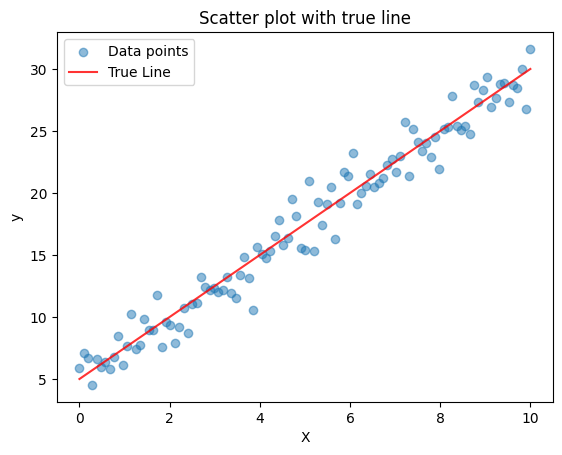

In [12]:
# =========================================================
# MODULE 3: GENRATING SYNTHETIC FEATURE X AND TARGET Y
# =========================================================

np.random.seed(46) #To get the same value every time

#Feature X
X=np.linspace(0,10,105)

#Trure weight w and bias
t_w,t_b=2.5,5.0

#Adding randomness 
noise = np.random.normal(0,1.5,size=(len(X)))

#Target values
y = t_w*X + t_b +noise

#Reshaping the raw 1D date into explicit 2D Matrix of [m x 1]
X_global = X.reshape(-1,1)
y_global = y.reshape(-1,1)# -1 to let NumPy calculate one dimension automatically
print(f"Shape of X :{X_global.shape} and y :{y_global.shape}")

#Visulization
plt.scatter(X,y,alpha=0.5,label='Data points')
plt.plot(X,t_w*X + t_b,alpha=0.8,label="True Line",color='red')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Scatter plot with true line')
plt.legend()
plt.show()

In [13]:
# =====================================================================
# MODULE 4: EXECUTION & HYPERPARAMETERS
# =====================================================================
learning_rate = 0.01
batch_size_setting = 20  # Groups of 20 rows (Creates exactly 5 batches per epoch)
total_epochs = 400

# Train the model
final_theta, loss_trace = train_mini_batch(X_global, y_global, learning_rate, batch_size_setting, total_epochs)

print("\n--- Training Completed Successfully ---")
print(f"True Underlying Model Target: w = {t_w:.1f}, b = {t_b:.1f}")
print(f"Mini-Batch Final Output Line: w = {final_theta[1,0]:.3f}, b = {final_theta[0,0]:.3f}")

--- Starting Mini-Batch SGD Training ---
Batch Size: 20 | Total Full Batches per Epoch: 5


--- Training Completed Successfully ---
True Underlying Model Target: w = 2.5, b = 5.0
Mini-Batch Final Output Line: w = 2.477, b = 4.943


--------------------------------------------------------------------------------
--- Starting Mini-Batch SGD Training ---
Batch Size: 20 | Total Full Batches per Epoch: 5

For Learning rate: 0.0001
converges slowly and may still be far from optimum after 400 iterations. (stable but slower convergence)

--- Training Completed Successfully ---
True Underlying Model Target: w = 2.5, b = 5.0
Mini-Batch Final Output Line: w = 3.120, b = 0.735
--------------------------------------------------------------------------------
--- Starting Mini-Batch SGD Training ---
Batch Size: 20 | Total Full Batches per Epoch: 5



For Learning rate: 0.01
Learning rate is good and model converges nicely. (good convergence)

--- Training Completed Successfully ---
True Underlying Model Target: w = 2.5, b = 5.0
Mini-Batch Final Output Line: w = 2.507, b = 4.933
--------------------------------------------------------------------------------
--- Starting Mini-Batch SGD Training ---
Batch Size: 20 | Total Full Batches per Epoch: 5

For Learning rate: 0.25
Learning rate is too high makes the model diverge. (unstable divergence)

--- Training Completed Successfully ---
True Underlying Model Target: w = 2.5, b = 5.0
Mini-Batch Final Output Line: w = nan, b = nan
--------------------------------------------------------------------------------


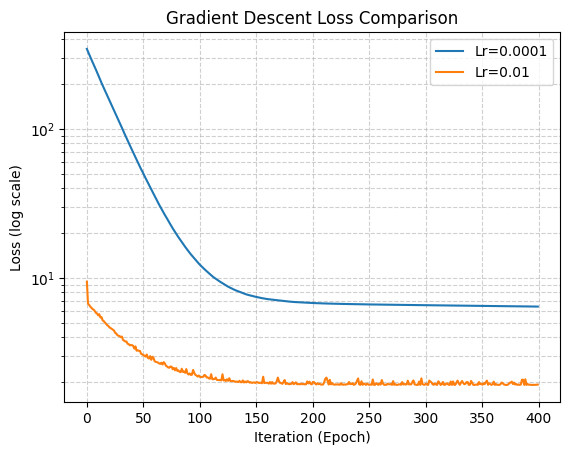

In [ ]:

# =======================================================================
# MODULE 5: INITIALIZATION FOR TRAINING (CHECKING DIFFRENT LEARNING RATE)
# =======================================================================
learning_rate = [0.0001, 0.01, 0.25]
total_epochs = 400
batch_size_setting = 20 

fig, ax = plt.subplots()
print("----" * 20)

for i in range(len(learning_rate)):
    
    
    # Running model for different learning rate
    final_theta, loss_trace = train_mini_batch(X_global, y_global, learning_rate[i], batch_size_setting, total_epochs)
    b_final = final_theta[0,0]
    w_final = final_theta[1,0]
    
    print(f"For Learning rate: {learning_rate[i]}")
    

    if np.isnan(w_final) or np.isnan(b_final):
        print("Learning rate is too high makes the model diverge. (unstable divergence)")
        warnings.filterwarnings("ignore", category=RuntimeWarning) # Ignore warnings as w=nan, b=nan
        
    elif abs(t_w - w_final) < 1e-1 or abs(t_b - b_final) < 1e-1:
        
        print("Learning rate is good and model converges nicely. (good convergence)")
        ax.plot(range(total_epochs), loss_trace, '-', label=f"Lr={learning_rate[i]}")
        
    else:
        print(f"converges slowly and may still be far from optimum after {total_epochs} iterations. (stable but slower convergence)")
        ax.plot(range(total_epochs), loss_trace, '-', label=f"Lr={learning_rate[i]}")        
        
    print("\n--- Training Completed Successfully ---")
    print(f"True Underlying Model Target: w = {t_w:.1f}, b = {t_b:.1f}")
    print(f"Mini-Batch Final Output Line: w = {final_theta[1,0]:.3f}, b = {final_theta[0,0]:.3f}")
    print("----" * 20)

ax.set_yscale('log')
ax.set_xlabel('Iteration (Epoch)')
ax.set_ylabel('Loss (log scale)')
ax.set_title('Gradient Descent Loss Comparison')
ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.legend()
plt.show()



--- Starting Mini-Batch SGD Training ---
Batch Size: 10 | Total Full Batches per Epoch: 10



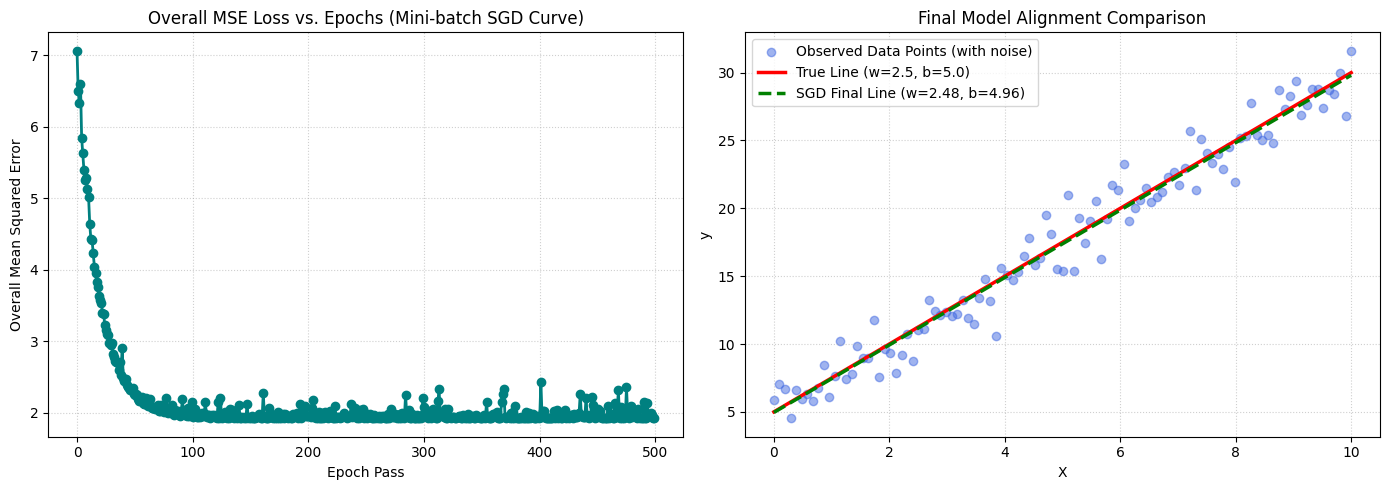

In [15]:

# ======================================================
# MODULE 6: VISUALIZING SGD CONVERGENCE & FINAL FIT
# ======================================================

learning_rate = 0.01
batch_size_setting = 10  # Groups of 20 rows (Creates exactly 5 batches per epoch)
total_epochs = 500

# Train the model
final_theta, loss_trace = train_mini_batch(X_global, y_global, learning_rate, batch_size_setting, total_epochs)
b_final = final_theta[0,0]
w_final = final_theta[1,0]

#visualisation of model prediction and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Loss Curve (Watching the error bowl drain)
ax1.plot(range(total_epochs), loss_trace, color='teal', marker='o', linewidth=2)
ax1.set_xlabel('Epoch Pass')
ax1.set_ylabel('Overall Mean Squared Error')
ax1.set_title('Overall MSE Loss vs. Epochs (Mini-batch SGD Curve)')
ax1.grid(True, linestyle=':', alpha=0.6)

# Plot B: Final Regression Fit against true underlying line
ax2.scatter(X, y, alpha=0.5, color='royalblue', label='Observed Data Points (with noise)')
ax2.plot(X, t_w*X + t_b, color='red', linewidth=2.5, label=f'True Line (w={t_w}, b={t_b})')
ax2.plot(X, w_final*X + b_final, color='green', linestyle='--', linewidth=2.5, label=f'SGD Final Line (w={w_final:.2f}, b={b_final:.2f})')
ax2.set_xlabel('X')
ax2.set_ylabel('y')
ax2.set_title('Final Model Alignment Comparison')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
